# PeMS 字段关系验证分析

## 验证目标

1. **Samples = Σ Lane_N_Samples** ？
2. **Pct_Observed = (LaneN_Observed=1 的车道数 / 总车道数) × 100** ？
3. **Lane_N_Samples 最大值是否为 10** ？
4. **当且仅当 Lane_N_Samples=10 时 Lane_N_Observed=1** ？

In [20]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

print("库加载完成！")

库加载完成！


## 1. 配置路径

In [21]:
# ============== 配置区域 ==============
# 原始数据文件夹
DATA_FOLDER = "/data/yuzhang_fei/PEMS/PEMSD3_2025"

# 元数据文件夹
META_FOLDER = "../d03_meta"

# 选择要分析的日期
TARGET_DATE = "2025_01_15"  # 格式：YYYY_MM_DD

# 输出目录
OUTPUT_DIR = "../output/field_relation_analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 构建数据文件路径
data_file = os.path.join(DATA_FOLDER, f"d03_text_station_5min_{TARGET_DATE}.txt")
print(f"数据文件: {data_file}")
print(f"  存在: {os.path.exists(data_file)}")

# 查找元数据文件：找到 <= TARGET_DATE 的最近日期
import re
import glob
from datetime import datetime

def find_nearest_meta_file(meta_folder, target_date_str):
    """
    查找小于等于目标日期的最近元数据文件
    """
    # 解析目标日期
    target_date = datetime.strptime(target_date_str, '%Y_%m_%d')
    
    # 查找所有元数据文件
    meta_files = glob.glob(os.path.join(meta_folder, "d*_text_meta_*.txt"))
    
    if not meta_files:
        return None, None
    
    # 解析每个文件的日期
    file_dates = []
    for f in meta_files:
        match = re.search(r'(\d{4})_(\d{2})_(\d{2})', os.path.basename(f))
        if match:
            file_date = datetime(int(match.group(1)), int(match.group(2)), int(match.group(3)))
            file_dates.append((file_date, f))
    
    if not file_dates:
        return None, None
    
    # 找到 <= target_date 的最近文件
    valid_files = [(d, f) for d, f in file_dates if d <= target_date]
    
    if valid_files:
        # 返回最近的（日期最大的）
        return max(valid_files, key=lambda x: x[0])
    else:
        # 如果没有更早的，返回最早的文件
        return min(file_dates, key=lambda x: x[0])

# 查找元数据文件
meta_date, meta_file = find_nearest_meta_file(META_FOLDER, TARGET_DATE)

if meta_file:
    print(f"\n元数据文件: {meta_file}")
    print(f"  元数据日期: {meta_date.strftime('%Y-%m-%d')}")
    print(f"  目标数据日期: {TARGET_DATE.replace('_', '-')}")
    print(f"  存在: {os.path.exists(meta_file)}")
else:
    print(f"\n错误: 未找到元数据文件！")

数据文件: /data/yuzhang_fei/PEMS/PEMSD3_2025/d03_text_station_5min_2025_01_15.txt
  存在: True

元数据文件: ../d03_meta/d03_text_meta_2024_11_27.txt
  元数据日期: 2024-11-27
  目标数据日期: 2025-01-15
  存在: True


## 2. 定义列名并加载数据

In [22]:
MAX_LANES = 8

# 基础字段
BASE_COLUMNS = [
    'Timestamp', 'Station', 'District', 'Freeway', 'Direction',
    'Lane_Type', 'Station_Length', 'Samples', 'Pct_Observed',
    'Total_Flow', 'Avg_Occupancy', 'Avg_Speed'
]

# 车道字段
LANE_COLUMNS = []
for i in range(1, MAX_LANES + 1):
    LANE_COLUMNS.extend([
        f'Lane{i}_Samples', 
        f'Lane{i}_Flow', 
        f'Lane{i}_Avg_Occ',
        f'Lane{i}_Avg_Speed', 
        f'Lane{i}_Observed'
    ])

ALL_COLUMNS = BASE_COLUMNS + LANE_COLUMNS

# 元数据列名
META_COLUMNS = [
    'ID', 'Fwy', 'Dir', 'District', 'County', 'City', 
    'State_PM', 'Abs_PM', 'Latitude', 'Longitude', 'Length',
    'Type', 'Lanes', 'Name', 'User_ID_1', 'User_ID_2', 
    'User_ID_3', 'User_ID_4'
]

print(f"数据列数: {len(ALL_COLUMNS)}")
print(f"元数据列数: {len(META_COLUMNS)}")

数据列数: 52
元数据列数: 18


In [23]:
# 加载交通数据
print(f"加载交通数据: {TARGET_DATE}...")
df = pd.read_csv(
    data_file, 
    header=None, 
    names=ALL_COLUMNS, 
    dtype={'Station': str},
    low_memory=False
)
print(f"交通数据: {len(df):,} 行, {len(df.columns)} 列")

# 加载元数据
print(f"\n加载元数据...")
meta_df = pd.read_csv(
    meta_file,
    sep='\t',
    names=META_COLUMNS,
    header=0,
    dtype={'ID': str, 'Fwy': str}
)
print(f"元数据: {len(meta_df):,} 个站点")

# 创建站点-车道数映射
station_lanes = meta_df.set_index('ID')['Lanes'].to_dict()
print(f"\n车道数分布:")
print(meta_df['Lanes'].value_counts().sort_index())

加载交通数据: 2025_01_15...
交通数据: 535,392 行, 52 列

加载元数据...
元数据: 1,859 个站点

车道数分布:
Lanes
1    824
2    562
3    267
4    151
5     51
6      4
Name: count, dtype: int64


In [24]:
# 添加车道数到交通数据
df['Lanes'] = df['Station'].map(station_lanes)
print(f"成功匹配车道数的记录: {df['Lanes'].notna().sum():,} / {len(df):,}")
print(f"未匹配的站点数: {df[df['Lanes'].isna()]['Station'].nunique()}")

成功匹配车道数的记录: 535,392 / 535,392
未匹配的站点数: 0


## 3. 验证关系 1: Samples = Σ Lane_N_Samples

In [25]:
print("="*60)
print("验证关系 1: Samples = Σ Lane_N_Samples")
print("="*60)

# 计算各车道 Samples 之和
lane_samples_cols = [f'Lane{i}_Samples' for i in range(1, MAX_LANES + 1)]
df['Sum_Lane_Samples'] = df[lane_samples_cols].sum(axis=1, skipna=True)

# 比较
df['Samples_Match'] = (df['Samples'] == df['Sum_Lane_Samples'])

match_rate = df['Samples_Match'].mean() * 100
print(f"\n匹配率: {match_rate:.4f}%")
print(f"匹配记录数: {df['Samples_Match'].sum():,} / {len(df):,}")

# 显示不匹配的示例
mismatch = df[~df['Samples_Match']]
print(f"\n不匹配记录数: {len(mismatch):,}")

if len(mismatch) > 0:
    print("\n不匹配示例:")
    display_cols = ['Station', 'Lanes', 'Samples', 'Sum_Lane_Samples'] + lane_samples_cols[:4]
    display(mismatch[display_cols].head(10))

验证关系 1: Samples = Σ Lane_N_Samples

匹配率: 100.0000%
匹配记录数: 535,392 / 535,392

不匹配记录数: 0


## 4. 验证关系 2: Pct_Observed = (Observed=1 的车道数 / 总车道数) × 100

In [26]:
print("="*60)
print("验证关系 2: Pct_Observed = (Observed=1 的车道数 / 总车道数) × 100")
print("="*60)

# 计算每行中 Observed=1 的车道数
lane_observed_cols = [f'Lane{i}_Observed' for i in range(1, MAX_LANES + 1)]
df['Count_Observed_1'] = (df[lane_observed_cols] == 1).sum(axis=1)

# 计算有数据的车道数（非NaN的车道）
df['Count_Active_Lanes'] = df[lane_observed_cols].notna().sum(axis=1)

# 计算预期的 Pct_Observed
df['Calc_Pct_Observed'] = (df['Count_Observed_1'] / df['Lanes'] * 100).round(2)

# 比较（允许一定误差）
df['Pct_Match'] = np.abs(df['Pct_Observed'] - df['Calc_Pct_Observed']) < 0.01

match_rate = df['Pct_Match'].mean() * 100
print(f"\n精确匹配率: {match_rate:.4f}%")

# 允许更大误差
df['Pct_Match_1'] = np.abs(df['Pct_Observed'] - df['Calc_Pct_Observed']) < 1
match_rate_1 = df['Pct_Match_1'].mean() * 100
print(f"允许±1误差的匹配率: {match_rate_1:.4f}%")

# 显示比较结果
print("\n比较示例:")
display_cols = ['Station', 'Lanes', 'Pct_Observed', 'Calc_Pct_Observed', 
                'Count_Observed_1', 'Count_Active_Lanes']
display(df[display_cols].head(20))

验证关系 2: Pct_Observed = (Observed=1 的车道数 / 总车道数) × 100

精确匹配率: 97.3229%
允许±1误差的匹配率: 98.4215%

比较示例:


,Station,Lanes,Pct_Observed,Calc_Pct_Observed,Count_Observed_1,Count_Active_Lanes
0,308511,2,50,50.00,1,8
1,308512,2,0,0.00,0,8
2,311831,1,100,100.00,1,8
3,311832,1,100,100.00,1,8
4,311844,2,100,100.00,2,8
5,311847,3,100,100.00,3,8
6,311864,1,0,0.00,0,8
7,311903,3,33,33.33,1,8
8,311930,3,100,100.00,3,8
9,311973,1,100,100.00,1,8


In [27]:
# 分析不匹配的情况
mismatch_pct = df[~df['Pct_Match_1']]
print(f"不匹配记录数 (误差>1): {len(mismatch_pct):,}")

if len(mismatch_pct) > 0:
    print("\n不匹配示例:")
    display_cols = ['Station', 'Lanes', 'Pct_Observed', 'Calc_Pct_Observed', 
                    'Count_Observed_1', 'Count_Active_Lanes'] + lane_observed_cols[:8]
    display(mismatch_pct[display_cols].head(10))
    
    # 计算差值分布
    diff = df['Pct_Observed'] - df['Calc_Pct_Observed']
    print(f"\n差值统计:")
    print(diff.describe())

不匹配记录数 (误差>1): 8,451

不匹配示例:


,Station,Lanes,Pct_Observed,Calc_Pct_Observed,Count_Observed_1,Count_Active_Lanes,Lane1_Observed,Lane2_Observed,Lane3_Observed,Lane4_Observed,Lane5_Observed,Lane6_Observed,Lane7_Observed,Lane8_Observed
168,313426,5,100,80.00,4,8,1,1,1,1,0,0,0,0
176,313475,5,100,80.00,4,8,1,1,1,1,0,0,0,0
264,314421,2,100,50.00,1,8,1,0,0,0,0,0,0,0
292,314599,2,100,50.00,1,8,0,1,0,0,0,0,0,0
300,314649,2,100,50.00,1,8,0,1,0,0,0,0,0,0
496,316143,5,100,20.00,1,8,0,0,0,0,1,0,0,0
564,316666,3,100,66.67,2,8,1,1,0,0,0,0,0,0
565,316670,3,100,66.67,2,8,0,1,1,0,0,0,0,0
612,317002,3,100,66.67,2,8,0,1,1,0,0,0,0,0
613,317003,3,100,66.67,2,8,0,1,1,0,0,0,0,0



差值统计:
count    535392.000000
mean          0.706007
std           5.917139
min          -0.330000
25%           0.000000
50%           0.000000
75%           0.000000
max          83.330000
dtype: float64


## 5. 验证关系 3: Lane_N_Samples 最大值是否为 10

In [28]:
print("="*60)
print("验证关系 3: Lane_N_Samples 的最大值是否为 10")
print("="*60)

# 统计所有车道 Samples 的分布
all_lane_samples = []
for i in range(1, MAX_LANES + 1):
    col = f'Lane{i}_Samples'
    samples = df[col].dropna()
    if len(samples) > 0:
        all_lane_samples.extend(samples.tolist())

all_lane_samples = pd.Series(all_lane_samples)
print(f"\n所有 Lane_N_Samples 的统计:")
print(all_lane_samples.describe())

print(f"\n最大值: {all_lane_samples.max()}")
print(f"最小值: {all_lane_samples.min()}")

# 分布
print(f"\nLane_N_Samples 值分布:")
value_counts = all_lane_samples.value_counts().sort_index()
print(value_counts)

# 计算占比
print(f"\n占比:")
for val, count in value_counts.items():
    pct = count / len(all_lane_samples) * 100
    print(f"  {val}: {count:,} ({pct:.2f}%)")

验证关系 3: Lane_N_Samples 的最大值是否为 10

所有 Lane_N_Samples 的统计:
count    1.030464e+06
mean     8.203853e+00
std      3.568273e+00
min      0.000000e+00
25%      9.000000e+00
50%      1.000000e+01
75%      1.000000e+01
max      2.000000e+01
dtype: float64

最大值: 20.0
最小值: 0.0

Lane_N_Samples 值分布:
0.0     128118
1.0      13977
2.0      11594
3.0      20287
4.0      11458
5.0       2606
6.0       2767
7.0       8732
8.0      24995
9.0      42399
10.0    763247
11.0        44
12.0         2
13.0         4
14.0        11
15.0         2
17.0         1
18.0         6
19.0         9
20.0       205
Name: count, dtype: int64

占比:
  0.0: 128,118 (12.43%)
  1.0: 13,977 (1.36%)
  2.0: 11,594 (1.13%)
  3.0: 20,287 (1.97%)
  4.0: 11,458 (1.11%)
  5.0: 2,606 (0.25%)
  6.0: 2,767 (0.27%)
  7.0: 8,732 (0.85%)
  8.0: 24,995 (2.43%)
  9.0: 42,399 (4.11%)
  10.0: 763,247 (74.07%)
  11.0: 44 (0.00%)
  12.0: 2 (0.00%)
  13.0: 4 (0.00%)
  14.0: 11 (0.00%)
  15.0: 2 (0.00%)
  17.0: 1 (0.00%)
  18.0: 6 (0.00%)
  19.0:

In [29]:
# 每个车道分别统计
print("\n各车道 Samples 统计:")
lane_stats = []
for i in range(1, MAX_LANES + 1):
    col = f'Lane{i}_Samples'
    samples = df[col].dropna()
    if len(samples) > 0:
        lane_stats.append({
            'Lane': i,
            'Count': len(samples),
            'Min': samples.min(),
            'Max': samples.max(),
            'Mean': samples.mean(),
            'Pct_10': (samples == 10).mean() * 100,
            'Pct_0': (samples == 0).mean() * 100
        })

lane_stats_df = pd.DataFrame(lane_stats)
display(lane_stats_df.round(2))


各车道 Samples 统计:


,Lane,Count,Min,Max,Mean,Pct_10,Pct_0
0,1,525888,0.0,20.0,8.35,75.46,11.08
1,2,295488,0.0,20.0,8.16,73.70,12.64
2,3,134496,0.0,11.0,7.98,71.84,14.66
3,4,58752,0.0,11.0,7.77,69.74,16.94
4,5,14688,0.0,11.0,7.58,68.58,19.30
5,6,1152,0.0,11.0,9.05,82.73,2.17


## 6. 验证关系 4: 当且仅当 Lane_N_Samples=10 时 Lane_N_Observed=1

In [30]:
print("="*60)
print("验证关系 4: 当且仅当 Lane_N_Samples=10 时 Lane_N_Observed=1")
print("="*60)

# 分析 Samples 与 Observed 的对应关系
relation_stats = []

for i in range(1, MAX_LANES + 1):
    samples_col = f'Lane{i}_Samples'
    observed_col = f'Lane{i}_Observed'
    
    # 只看有数据的行
    valid = df[[samples_col, observed_col]].dropna()
    if len(valid) == 0:
        continue
    
    # 四种情况统计
    samples_10_obs_1 = ((valid[samples_col] == 10) & (valid[observed_col] == 1)).sum()
    samples_10_obs_0 = ((valid[samples_col] == 10) & (valid[observed_col] == 0)).sum()
    samples_lt10_obs_1 = ((valid[samples_col] < 10) & (valid[observed_col] == 1)).sum()
    samples_lt10_obs_0 = ((valid[samples_col] < 10) & (valid[observed_col] == 0)).sum()
    
    total = len(valid)
    
    relation_stats.append({
        'Lane': i,
        'Total': total,
        'Samples=10 & Obs=1': samples_10_obs_1,
        'Samples=10 & Obs=0': samples_10_obs_0,
        'Samples<10 & Obs=1': samples_lt10_obs_1,
        'Samples<10 & Obs=0': samples_lt10_obs_0,
        '符合假设': samples_10_obs_1 + samples_lt10_obs_0,
        '符合率(%)': (samples_10_obs_1 + samples_lt10_obs_0) / total * 100
    })

relation_df = pd.DataFrame(relation_stats)
print("\n各车道 Samples-Observed 关系统计:")
display(relation_df.round(2))

验证关系 4: 当且仅当 Lane_N_Samples=10 时 Lane_N_Observed=1

各车道 Samples-Observed 关系统计:


,Lane,Total,Samples=10 & Obs=1,Samples=10 & Obs=0,Samples<10 & Obs=1,Samples<10 & Obs=0,符合假设,符合率(%)
0,1,525888,362528,34320,62957,65837,428365,81.46
1,2,295488,197254,20522,35310,42376,239630,81.10
2,3,134496,86723,9903,16510,21356,108079,80.36
3,4,58752,36337,4634,7056,10721,47058,80.10
4,5,14688,8567,1506,1585,3028,11595,78.94
5,6,1152,953,0,172,25,978,84.90


In [31]:
# 汇总所有车道
print("\n汇总统计:")
total_符合假设 = relation_df['符合假设'].sum()
total_total = relation_df['Total'].sum()
overall_rate = total_符合假设 / total_total * 100

print(f"总记录数: {total_total:,}")
print(f"符合假设的记录数: {total_符合假设:,}")
print(f"整体符合率: {overall_rate:.4f}%")

# 不符合假设的情况
total_exception_1 = relation_df['Samples=10 & Obs=0'].sum()  # Samples=10 但 Observed=0
total_exception_2 = relation_df['Samples<10 & Obs=1'].sum()  # Samples<10 但 Observed=1

print(f"\n例外情况:")
print(f"  Samples=10 但 Observed=0: {total_exception_1:,} ({total_exception_1/total_total*100:.4f}%)")
print(f"  Samples<10 但 Observed=1: {total_exception_2:,} ({total_exception_2/total_total*100:.4f}%)")


汇总统计:
总记录数: 1,030,464
符合假设的记录数: 835,705
整体符合率: 81.0999%

例外情况:
  Samples=10 但 Observed=0: 70,885 (6.8789%)
  Samples<10 但 Observed=1: 123,590 (11.9936%)


In [32]:
# 查看例外情况的具体记录
print("\n查看 Samples<10 但 Observed=1 的记录示例:")

# 找一个例子
for i in range(1, MAX_LANES + 1):
    samples_col = f'Lane{i}_Samples'
    observed_col = f'Lane{i}_Observed'
    
    exception = df[(df[samples_col] < 10) & (df[observed_col] == 1)]
    if len(exception) > 0:
        print(f"\nLane {i} 的例外记录 ({len(exception)} 条):")
        display_cols = ['Station', 'Timestamp', samples_col, observed_col, 'Samples', 'Pct_Observed']
        display(exception[display_cols].head(5))
        break


查看 Samples<10 但 Observed=1 的记录示例:

Lane 1 的例外记录 (62957 条):


,Station,Timestamp,Lane1_Samples,Lane1_Observed,Samples,Pct_Observed
8,311930,01/15/2025 00:00:00,9.0,1,27,100
41,312382,01/15/2025 00:00:00,9.0,1,25,100
42,312383,01/15/2025 00:00:00,9.0,1,18,100
43,312386,01/15/2025 00:00:00,9.0,1,27,100
44,312387,01/15/2025 00:00:00,9.0,1,18,100


## 7. 详细对比输出（便于人工检查）

In [33]:
# 创建详细对比表
print("创建详细对比表...")

# 选择有代表性的记录（不同车道数、不同 Pct_Observed）
sample_records = []

# 按车道数分组采样
for lanes in sorted(df['Lanes'].dropna().unique()):
    subset = df[df['Lanes'] == lanes]
    if len(subset) > 0:
        # 从不同 Pct_Observed 范围采样
        for pct_range in [(0, 25), (25, 50), (50, 75), (75, 100), (100, 101)]:
            pct_subset = subset[(subset['Pct_Observed'] >= pct_range[0]) & 
                                (subset['Pct_Observed'] < pct_range[1])]
            if len(pct_subset) > 0:
                sample_records.append(pct_subset.sample(min(2, len(pct_subset))))

if sample_records:
    sample_df = pd.concat(sample_records).drop_duplicates()
else:
    sample_df = df.sample(50)

print(f"采样记录数: {len(sample_df)}")

创建详细对比表...


采样记录数: 42


In [34]:
# 创建便于人工比较的输出
compare_cols = ['Station', 'Timestamp', 'Lanes', 'Samples', 'Sum_Lane_Samples', 
                'Pct_Observed', 'Calc_Pct_Observed', 'Count_Observed_1', 'Count_Active_Lanes']

# 添加各车道的 Samples 和 Observed
for i in range(1, MAX_LANES + 1):
    compare_cols.append(f'Lane{i}_Samples')
    compare_cols.append(f'Lane{i}_Observed')

compare_df = sample_df[compare_cols].copy()
compare_df = compare_df.sort_values(['Lanes', 'Pct_Observed'])

print("详细对比表:")
display(compare_df.head(30))

详细对比表:


,Station,Timestamp,Lanes,Samples,Sum_Lane_Samples,Pct_Observed,Calc_Pct_Observed,Count_Observed_1,Count_Active_Lanes,Lane1_Samples,...,Lane4_Samples,Lane4_Observed,Lane5_Samples,Lane5_Observed,Lane6_Samples,Lane6_Observed,Lane7_Samples,Lane7_Observed,Lane8_Samples,Lane8_Observed
382882,3420052,01/15/2025 17:05:00,1,10,10.0,0,0.00,0,8,10.0,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
113818,315880,01/15/2025 05:05:00,1,10,10.0,0,0.00,0,8,10.0,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
528181,314138,01/15/2025 23:40:00,1,4,4.0,100,100.00,1,8,4.0,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
329356,314723,01/15/2025 14:45:00,1,10,10.0,100,100.00,1,8,10.0,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
258607,314001,01/15/2025 11:35:00,2,0,0.0,0,0.00,0,8,0.0,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
390409,312105,01/15/2025 17:30:00,2,0,0.0,0,0.00,0,8,0.0,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
345035,3019101,01/15/2025 15:25:00,2,20,20.0,50,50.00,1,8,10.0,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
181824,3070014,01/15/2025 08:05:00,2,20,20.0,50,50.00,1,8,10.0,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
434853,3411034,01/15/2025 19:25:00,2,20,20.0,100,100.00,2,8,10.0,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
279802,319481,01/15/2025 12:30:00,2,20,20.0,100,100.00,2,8,10.0,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0


In [35]:
# 保存详细对比表
output_file = os.path.join(OUTPUT_DIR, f'field_relation_comparison_{TARGET_DATE}.csv')
compare_df.to_csv(output_file, index=False)
print(f"已保存: {output_file}")

已保存: ../output/field_relation_analysis/field_relation_comparison_2025_01_15.csv


## 8. 汇总报告

In [36]:
print("\n" + "="*60)
print("汇总报告")
print("="*60)

print(f"\n数据日期: {TARGET_DATE}")
print(f"总记录数: {len(df):,}")
print(f"站点数: {df['Station'].nunique()}")

print(f"\n" + "-"*60)
print("关系验证结果:")
print("-"*60)

# 关系1
samples_match_rate = df['Samples_Match'].mean() * 100
print(f"\n1. Samples = Σ Lane_N_Samples")
print(f"   匹配率: {samples_match_rate:.4f}%")
print(f"   结论: {'✓ 完全成立' if samples_match_rate > 99.99 else '✗ 存在例外'}")

# 关系2
pct_match_rate = df['Pct_Match_1'].mean() * 100
print(f"\n2. Pct_Observed = (Observed=1 的车道数 / 总车道数) × 100")
print(f"   匹配率 (±1误差): {pct_match_rate:.4f}%")
print(f"   结论: {'✓ 基本成立' if pct_match_rate > 99 else '✗ 存在例外'}")

# 关系3
max_samples = all_lane_samples.max()
print(f"\n3. Lane_N_Samples 最大值是否为 10")
print(f"   实际最大值: {max_samples}")
print(f"   结论: {'✓ 成立' if max_samples == 10 else '✗ 不成立'}")

# 关系4
print(f"\n4. 当且仅当 Lane_N_Samples=10 时 Lane_N_Observed=1")
print(f"   整体符合率: {overall_rate:.4f}%")
print(f"   例外1 (Samples=10 但 Obs=0): {total_exception_1:,} ({total_exception_1/total_total*100:.4f}%)")
print(f"   例外2 (Samples<10 但 Obs=1): {total_exception_2:,} ({total_exception_2/total_total*100:.4f}%)")
print(f"   结论: {'✓ 基本成立' if overall_rate > 99 else '✗ 存在例外'}")

print(f"\n" + "-"*60)
print("Lane_N_Samples 分布:")
print("-"*60)
for val, count in value_counts.items():
    pct = count / len(all_lane_samples) * 100
    bar = '█' * int(pct / 2)
    print(f"  {val:2.0f}: {count:>10,} ({pct:5.2f}%) {bar}")


汇总报告

数据日期: 2025_01_15
总记录数: 535,392
站点数: 1859

------------------------------------------------------------
关系验证结果:
------------------------------------------------------------

1. Samples = Σ Lane_N_Samples
   匹配率: 100.0000%
   结论: ✓ 完全成立

2. Pct_Observed = (Observed=1 的车道数 / 总车道数) × 100
   匹配率 (±1误差): 98.4215%
   结论: ✗ 存在例外

3. Lane_N_Samples 最大值是否为 10
   实际最大值: 20.0
   结论: ✗ 不成立

4. 当且仅当 Lane_N_Samples=10 时 Lane_N_Observed=1
   整体符合率: 81.0999%
   例外1 (Samples=10 但 Obs=0): 70,885 (6.8789%)
   例外2 (Samples<10 但 Obs=1): 123,590 (11.9936%)
   结论: ✗ 存在例外

------------------------------------------------------------
Lane_N_Samples 分布:
------------------------------------------------------------
   0:    128,118 (12.43%) ██████
   1:     13,977 ( 1.36%) 
   2:     11,594 ( 1.13%) 
   3:     20,287 ( 1.97%) 
   4:     11,458 ( 1.11%) 
   5:      2,606 ( 0.25%) 
   6:      2,767 ( 0.27%) 
   7:      8,732 ( 0.85%) 
   8:     24,995 ( 2.43%) █
   9:     42,399 ( 4.11%) ██
  10:    763,247 (

In [37]:
# 保存汇总报告
report = f"""
PeMS 字段关系验证报告
{'='*60}

数据日期: {TARGET_DATE}
总记录数: {len(df):,}
站点数: {df['Station'].nunique()}

{'-'*60}
关系验证结果:
{'-'*60}

1. Samples = Σ Lane_N_Samples
   匹配率: {samples_match_rate:.4f}%
   结论: {'完全成立' if samples_match_rate > 99.99 else '存在例外'}

2. Pct_Observed = (Observed=1 的车道数 / 总车道数) × 100
   匹配率 (±1误差): {pct_match_rate:.4f}%
   结论: {'基本成立' if pct_match_rate > 99 else '存在例外'}

3. Lane_N_Samples 最大值是否为 10
   实际最大值: {max_samples}
   结论: {'成立' if max_samples == 10 else '不成立'}

4. 当且仅当 Lane_N_Samples=10 时 Lane_N_Observed=1
   整体符合率: {overall_rate:.4f}%
   例外1 (Samples=10 但 Obs=0): {total_exception_1:,} ({total_exception_1/total_total*100:.4f}%)
   例外2 (Samples<10 但 Obs=1): {total_exception_2:,} ({total_exception_2/total_total*100:.4f}%)
   结论: {'基本成立' if overall_rate > 99 else '存在例外'}

{'-'*60}
Lane_N_Samples 分布:
{'-'*60}
"""

for val, count in value_counts.items():
    pct = count / len(all_lane_samples) * 100
    report += f"  {val:2.0f}: {count:>10,} ({pct:5.2f}%)\n"

report_file = os.path.join(OUTPUT_DIR, f'field_relation_report_{TARGET_DATE}.txt')
with open(report_file, 'w') as f:
    f.write(report)
print(f"\n报告已保存: {report_file}")


报告已保存: ../output/field_relation_analysis/field_relation_report_2025_01_15.txt


## 9. 可视化

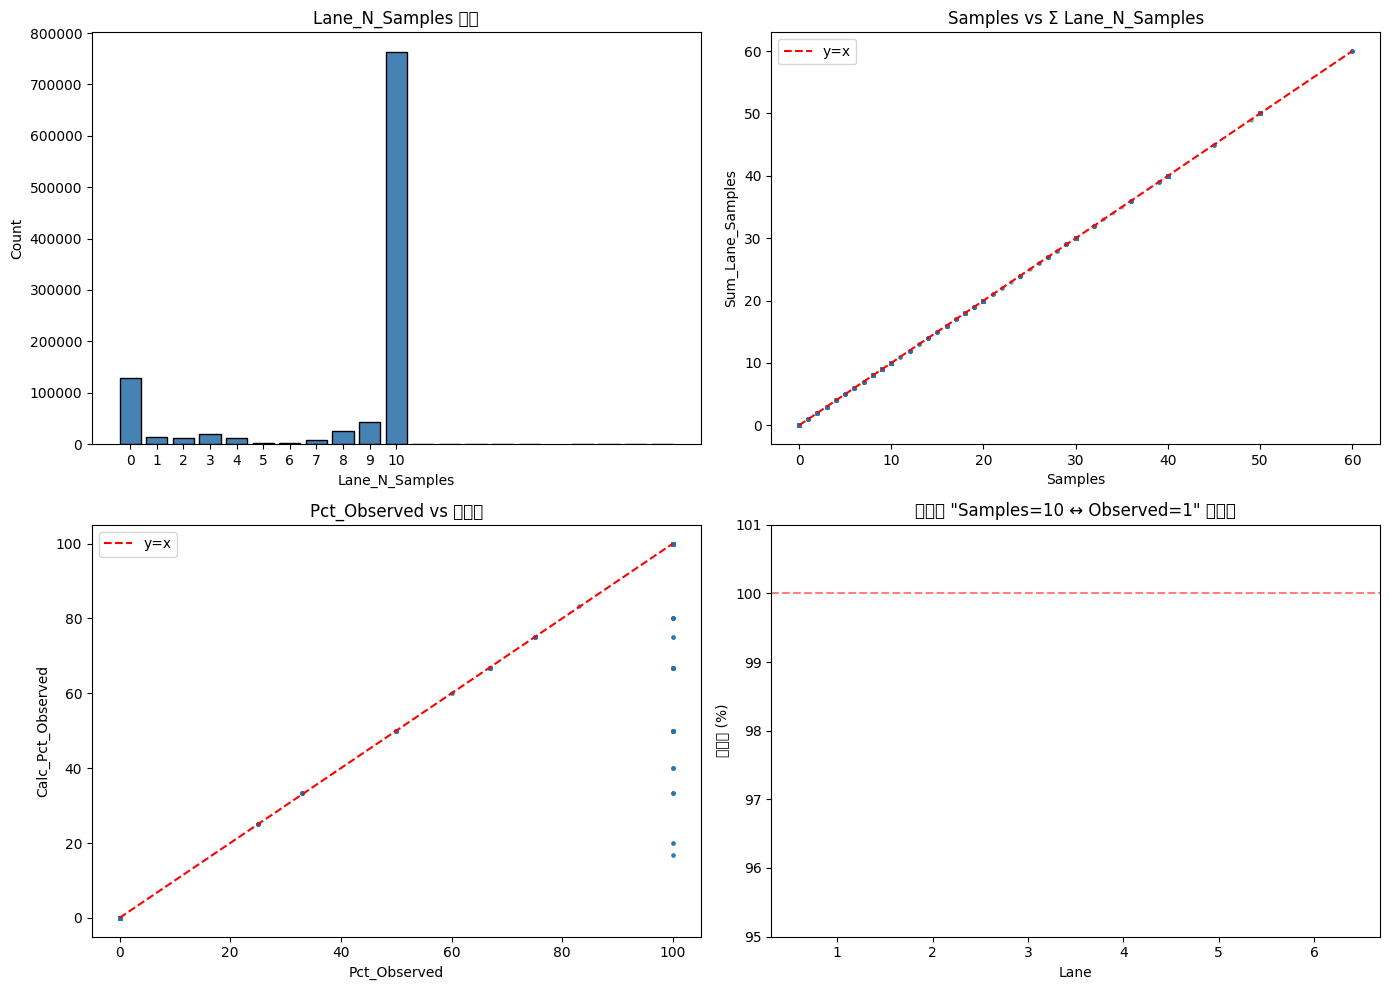

图表已保存


In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Lane_N_Samples 分布
axes[0, 0].bar(value_counts.index, value_counts.values, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Lane_N_Samples')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Lane_N_Samples 分布')
axes[0, 0].set_xticks(range(0, 11))

# 2. Samples vs Sum_Lane_Samples
sample = df.sample(min(10000, len(df)))
axes[0, 1].scatter(sample['Samples'], sample['Sum_Lane_Samples'], alpha=0.3, s=5)
axes[0, 1].plot([0, sample['Samples'].max()], [0, sample['Samples'].max()], 'r--', label='y=x')
axes[0, 1].set_xlabel('Samples')
axes[0, 1].set_ylabel('Sum_Lane_Samples')
axes[0, 1].set_title('Samples vs Σ Lane_N_Samples')
axes[0, 1].legend()

# 3. Pct_Observed vs Calc_Pct_Observed
axes[1, 0].scatter(sample['Pct_Observed'], sample['Calc_Pct_Observed'], alpha=0.3, s=5)
axes[1, 0].plot([0, 100], [0, 100], 'r--', label='y=x')
axes[1, 0].set_xlabel('Pct_Observed')
axes[1, 0].set_ylabel('Calc_Pct_Observed')
axes[1, 0].set_title('Pct_Observed vs 计算值')
axes[1, 0].legend()

# 4. 各车道符合率
axes[1, 1].bar(relation_df['Lane'], relation_df['符合率(%)'], color='green', edgecolor='black')
axes[1, 1].axhline(y=100, color='red', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Lane')
axes[1, 1].set_ylabel('符合率 (%)')
axes[1, 1].set_title('各车道 "Samples=10 ↔ Observed=1" 符合率')
axes[1, 1].set_ylim(95, 101)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'field_relation_analysis_{TARGET_DATE}.png'), dpi=150)
plt.show()
print(f"图表已保存")